* **Note:** Prendre une partie des compteurs: ID1 - ID20
* Prioriser les valeurs récentes (dates récentes )
* Pourquoi les compteurs ID_2, ID_6,ID_11, ID_20 sont à 0 sur toute la période?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!ls /content/drive/MyDrive/Projet-tutore-ML

df = pd.read_csv('/content/drive/MyDrive/Projet-tutore-ML/detection_fuite.csv')
df.head()

detection_fuite.csv


,valeur_active,valeur_date,libelle
0,35.0,2019-01-01,ID_1
1,0.0,2019-01-01,ID_2
2,2.0,2019-01-01,ID_3
3,38.0,2019-01-01,ID_4
4,38.0,2019-01-01,ID_5


## Analyse Exploratoire

In [7]:
df.describe()

,valeur_active
count,4.488080e+05
mean,1.160575e+03
std,3.013335e+05
min,-8.740000e+01
25%,7.972603e-01
50%,5.100000e+00
75%,2.000000e+01
max,9.999999e+07


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470900 entries, 0 to 470899
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   valeur_active  448808 non-null  float64
 1   valeur_date    470900 non-null  object 
 2   libelle        470900 non-null  object 
dtypes: float64(1), object(2)
memory usage: 10.8+ MB


In [9]:
df.describe(include='object')

,valeur_date,libelle
count,470900,470900
unique,2192,502
top,2024-12-18,ID_5
freq,477,2188


On transforme la date en datetime pour la rendre plus exploitable

In [10]:
df['valeur_date'] = pd.to_datetime(df['valeur_date'])
df['valeur_date'].head()

,valeur_date
0,2019-01-01
1,2019-01-01
2,2019-01-01
3,2019-01-01
4,2019-01-01


taille du dataset (470900, 3)
Nombre de compteurs : 502
Nombre de Jours répertoriés : 2192
Valeurs manquantes :


,total,pourcentage
valeur_active,22092,4.69
valeur_date,0,0.00
libelle,0,0.00


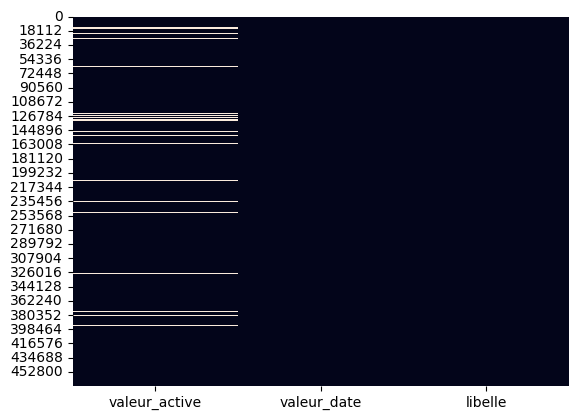

In [11]:
def show_isna_infos(df):
  print("taille du dataset", df.shape)
  print("Nombre de compteurs :", df['libelle'].nunique())
  print("Nombre de Jours répertoriés :", df['valeur_date'].nunique())
  print("Valeurs manquantes :")

  na_counts = df.isna().sum()
  na_counts_normalized = (na_counts / len(df) * 100).round(2)
  missing_table = pd.concat([na_counts,na_counts_normalized],axis=1)
  missing_table.columns = ["total", "pourcentage"]
  display(missing_table)

  sns.heatmap(df.isna(),cbar=False)

show_isna_infos(df)

on a moins de **5%** de valeurs manquantes pour la colonne "**valeur_active**" et on pourrait donc les supprimer.

Taille du dataset réduit: (39428, 3)
Cela représente 8.37% du DataFrame original (39428 lignes)
taille du dataset (39428, 3)
Nombre de compteurs : 20
Nombre de Jours répertoriés : 2192
Valeurs manquantes :


,total,pourcentage
valeur_active,284,0.72
valeur_date,0,0.00
libelle,0,0.00


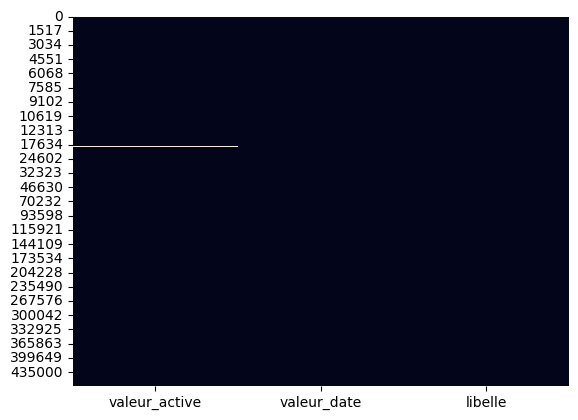

In [12]:
# on va reduire le nombre de compteurs à analyser. On prendra les 20 premiers compteurs (ID1...ID20)


ids = [f"ID_{i}" for i in range(1, 21)]

df_new = df[df['libelle'].isin(ids)]
df_new['libelle'].unique()

print("Taille du dataset réduit:",df_new.shape)

pourcentage = (len(df_new) / len(df)) * 100
print(f"Cela représente {pourcentage:.2f}% du DataFrame original ({len(df_new)} lignes)")
show_isna_infos(df_new)


In [13]:
df_new.describe()

,valeur_active,valeur_date
count,39144.000000,39428
mean,46.272602,2022-02-27 08:33:17.037638400
min,0.000000,2019-01-01 00:00:00
25%,0.900000,2020-09-01 00:00:00
50%,19.968200,2022-04-10 00:00:00
75%,46.799999,2023-08-22 00:00:00
max,1418.000000,2024-12-31 00:00:00
std,81.907551,NaN


### Distribution de la variable **valeur_active** pour les 20 premiers compteurs

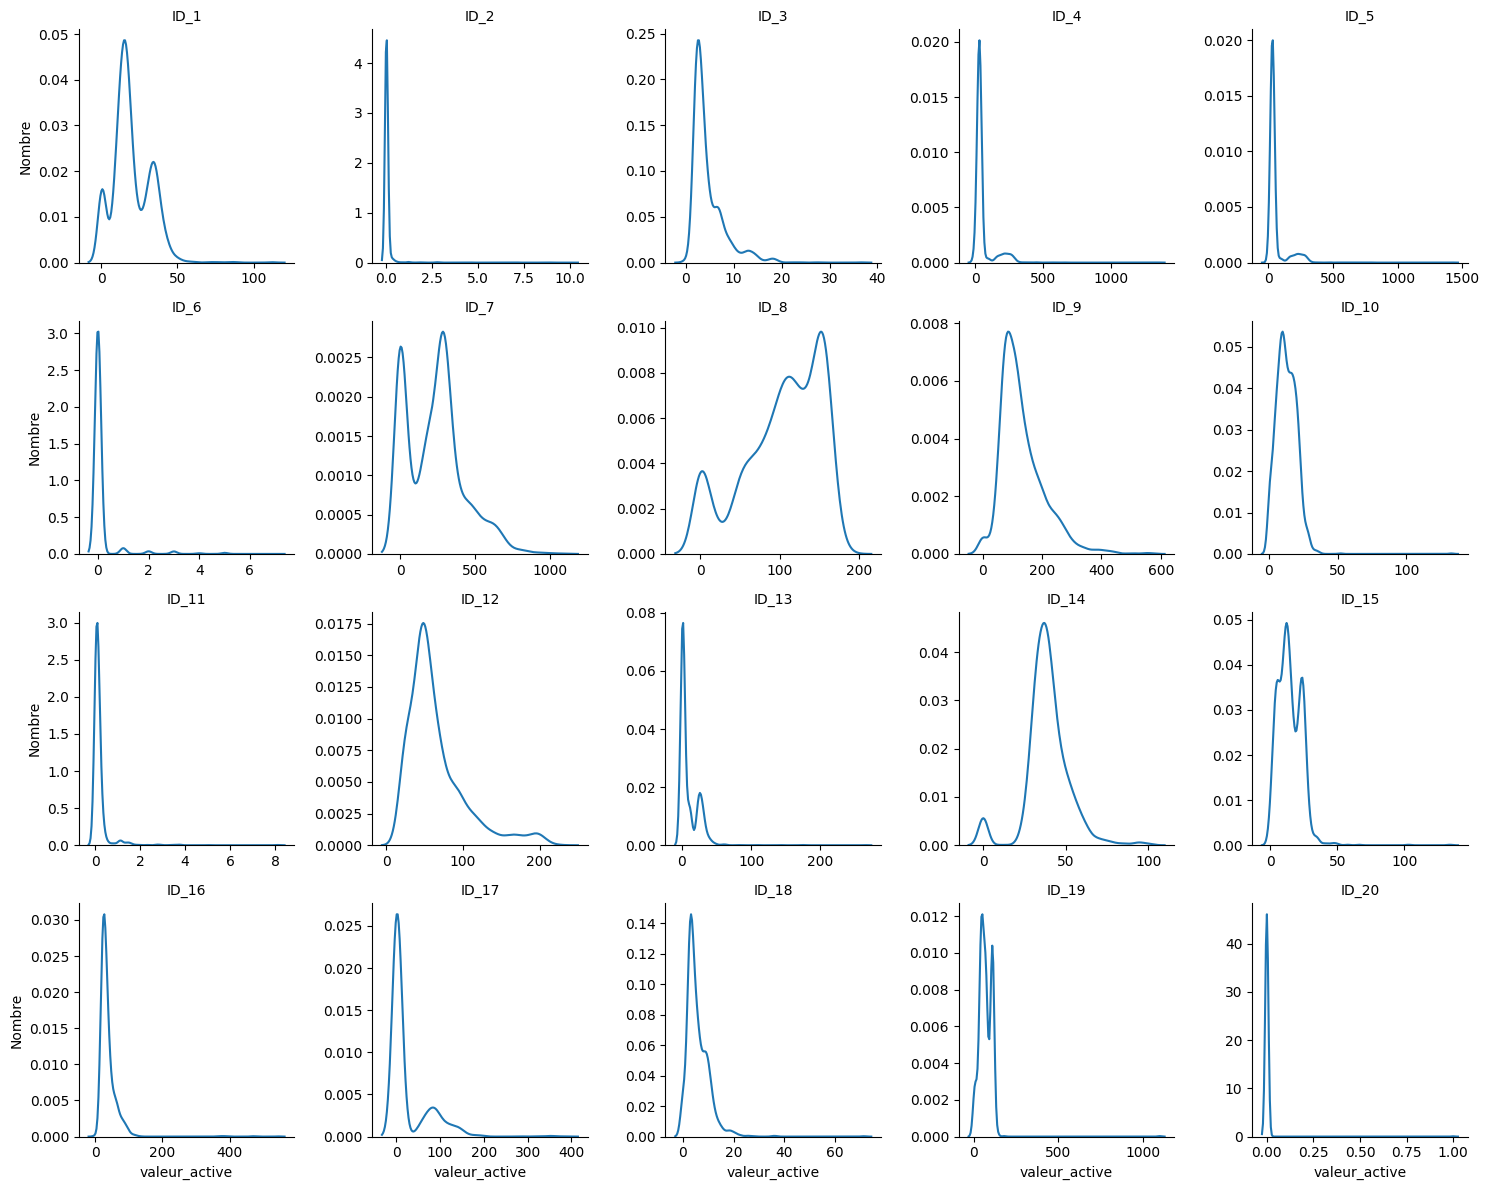

In [14]:
g = sns.FacetGrid(df_new, col="libelle", col_wrap=5, height=3, sharex=False, sharey=False)
g.map(sns.kdeplot, "valeur_active")
g.set_titles(col_template="{col_name}")
g.set_axis_labels("valeur_active", "Nombre")
plt.tight_layout()
plt.show()



* On a une asymétrie à droite pour la majorité des compteurs sauf le compteur **ID_19** pour lequel l'asymétrie est moins prononcée et **ID_13** qui présente une asymétrie négative  
* Il faudra peut-etre appliquer une transformation log des valeurs avant le training / Normliser les données

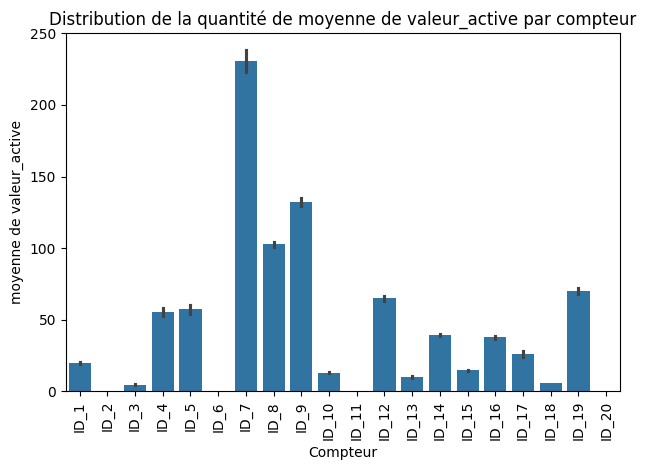

In [48]:
#  Distribution de la quantité de moyenne de valeur_active par compteur

sns.barplot(data=df_new, x='libelle', y='valeur_active')
plt.title('Distribution de la quantité de moyenne de valeur_active par compteur')
plt.xlabel('Compteur')
plt.ylabel('moyenne de valeur_active')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

* Il n'y a pas de valeurs pour les compteurs ID_2, ID_6,ID_11, ID_20
* Chercher pourquoi les valeurs sont nulles pour ces compteurs
* Observer plus de compteurs

## COMPTEUR ID_1

## Visualisation par année, par mois , par jour

In [15]:
# On crée de nouvelles variables : année, mois , jour de la semaine
df_new['annee'] = df_new['valeur_date'].dt.year
df_new["jour"] = df_new["valeur_date"].dt.day_name()
df_new["mois"] = df_new["valeur_date"].dt.month_name()


/tmp/ipython-input-788820636.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['annee'] = df_new['valeur_date'].dt.year
/tmp/ipython-input-788820636.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["jour"] = df_new["valeur_date"].dt.day_name()
/tmp/ipython-input-788820636.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [16]:
df_new['jour'].head()

,jour
0,Tuesday
1,Tuesday
2,Tuesday
3,Tuesday
4,Tuesday


#### Visualisation par année

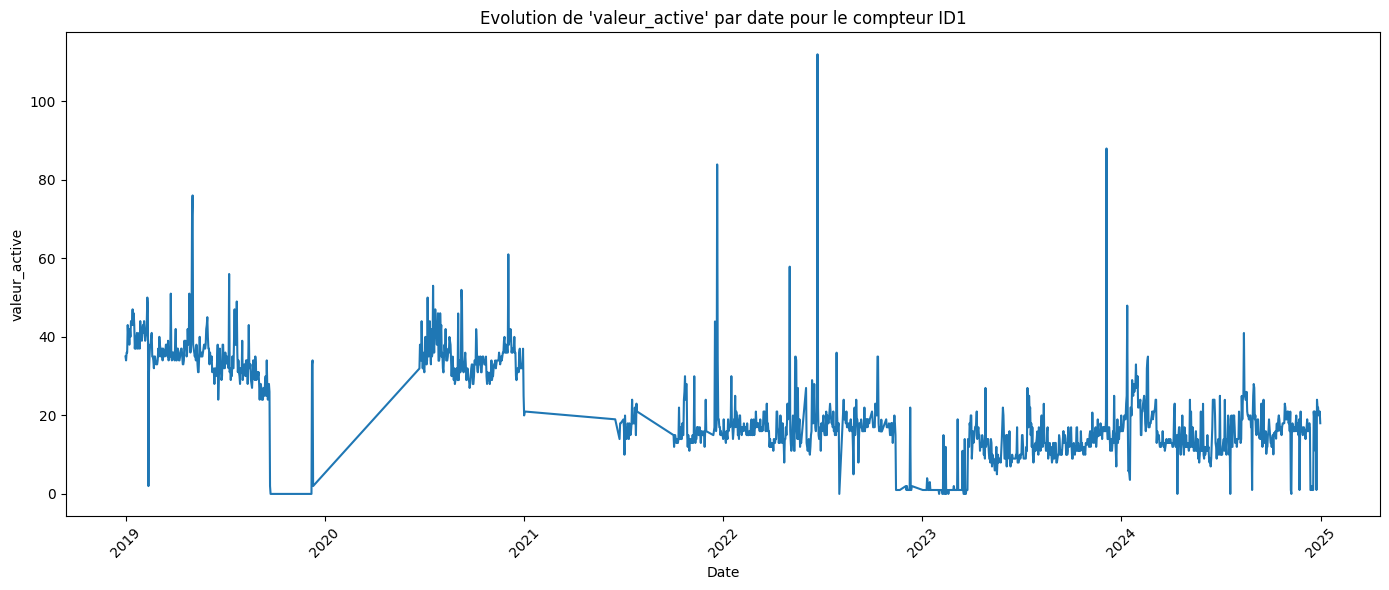

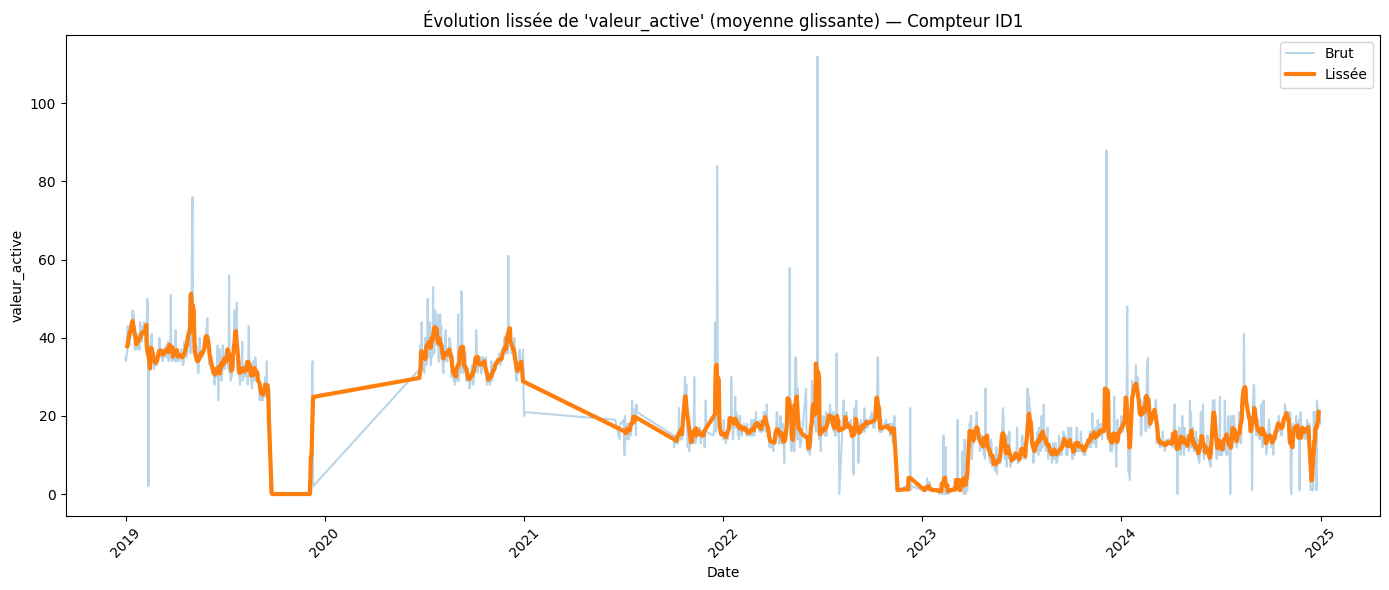

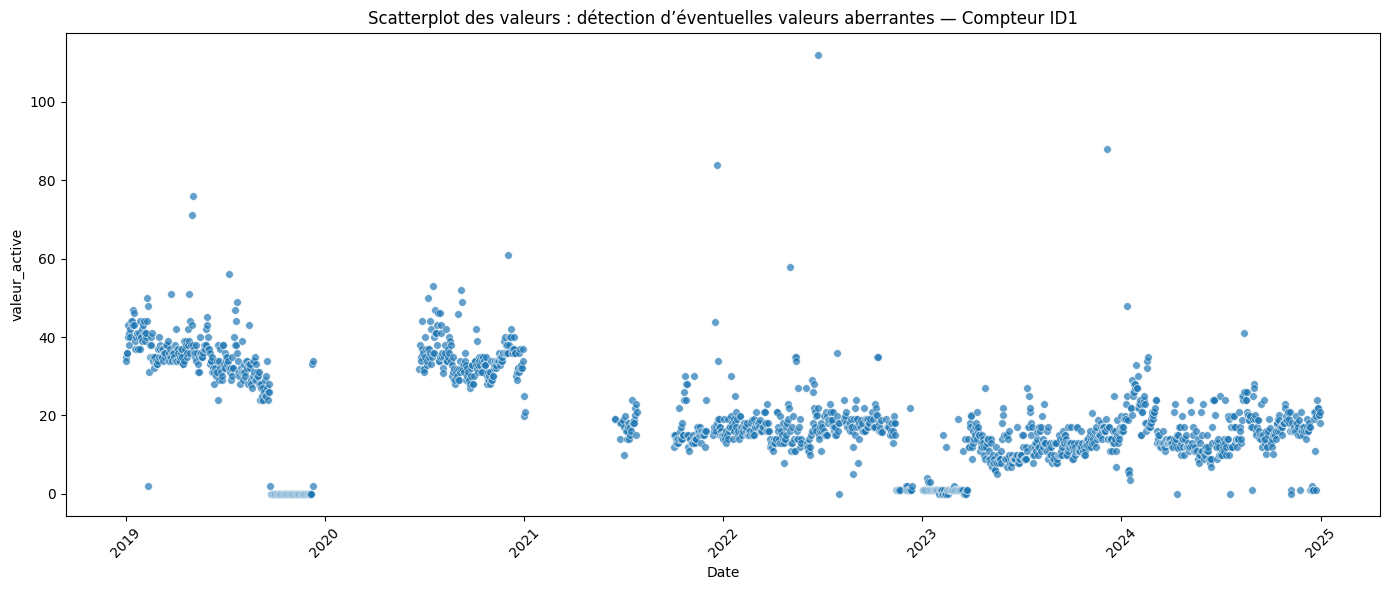

In [28]:
## Visualisation de la courbe brute du compteur 1 par date
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_new[df_new['libelle']=='ID_1'], x='valeur_date', y='valeur_active')
plt.title("Evolution de 'valeur_active' par date pour le compteur ID1")
plt.xlabel("Date")
plt.ylabel("valeur_active")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


df_id1 = df_new[df_new['libelle'] == 'ID_1'].copy()
df_id1 = df_id1.sort_values('valeur_date')

# lissage : moyenne glissante sur 7 points
df_id1['valeur_lissée'] = df_id1['valeur_active'].rolling(window=7, center=True).mean()

plt.figure(figsize=(14,6))
sns.lineplot(data=df_id1, x='valeur_date', y='valeur_active', alpha=0.3, label='Brut')
sns.lineplot(data=df_id1, x='valeur_date', y='valeur_lissée', linewidth=3, label='Lissée')
plt.title("Évolution lissée de 'valeur_active' (moyenne glissante) — Compteur ID1")
plt.xlabel("Date")
plt.ylabel("valeur_active")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Scatterplot pour identifier les valeurs abbérantes :
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=df_id1,
    x='valeur_date',
    y='valeur_active',
    s=30,        # taille des points
    alpha=0.7    # transparence pour repérer les clusters
)

plt.title("Scatterplot des valeurs : détection d’éventuelles valeurs aberrantes — Compteur ID1")
plt.xlabel("Date")
plt.ylabel("valeur_active")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Visualisation avec superposition des plots pour chaque année
# df_id1["jour_annee"] = df_id1["valeur_date"].dt.dayofyear
# plt.figure(figsize=(14,6))

# sns.lineplot(
#     data=df_id1,
#     x="jour_annee",
#     y="valeur_active",
#     hue="annee",
#     palette="viridis",
#     linewidth=2
# )

# plt.title("Superposition des tendances annuelles — Compteur ID_1")
# plt.xlabel("Jour de l'année")
# plt.ylabel("valeur_active")
# plt.tight_layout()
# plt.show()





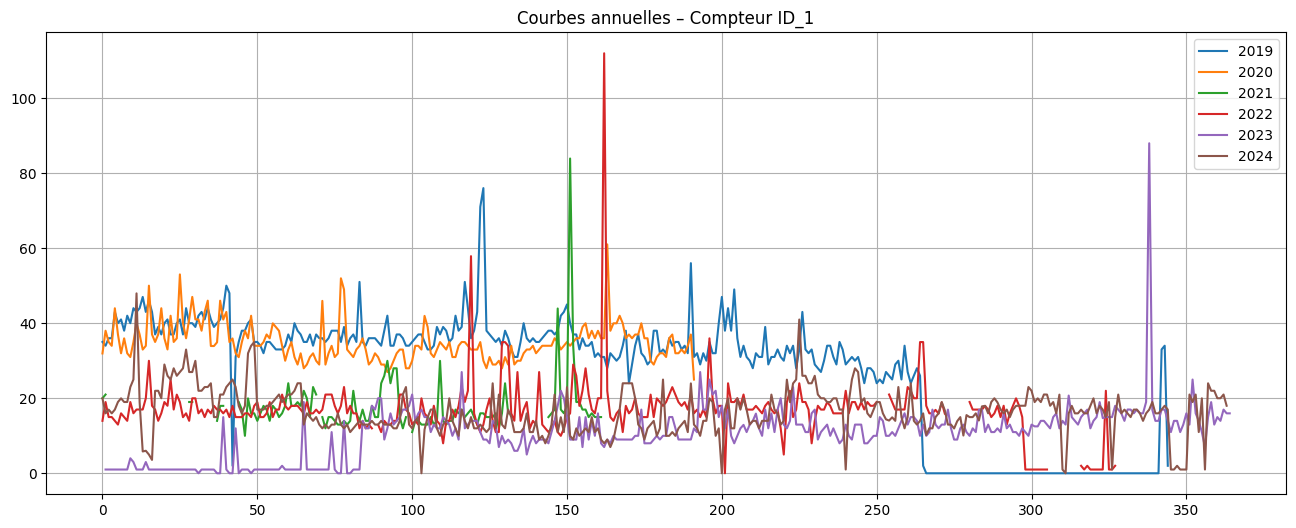

In [34]:
# Visualisation avec superposition des plots pour chaque année
def plot_years(df, meter_id):

    d = df[df['libelle'] == meter_id].set_index('valeur_date')
    years = sorted(d.index.year.unique())

    plt.figure(figsize=(16,6))

    for year in years:
        yearly = d.loc[str(year), 'valeur_active']
        plt.plot(yearly.values, label=str(year))

    plt.title(f'Courbes annuelles – Compteur {meter_id}')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_years(df_new,'ID_1')

* sur le dernier graphe on constate des pics qui se produisent à la meme periode pour différentes années:(2019 et 2022)

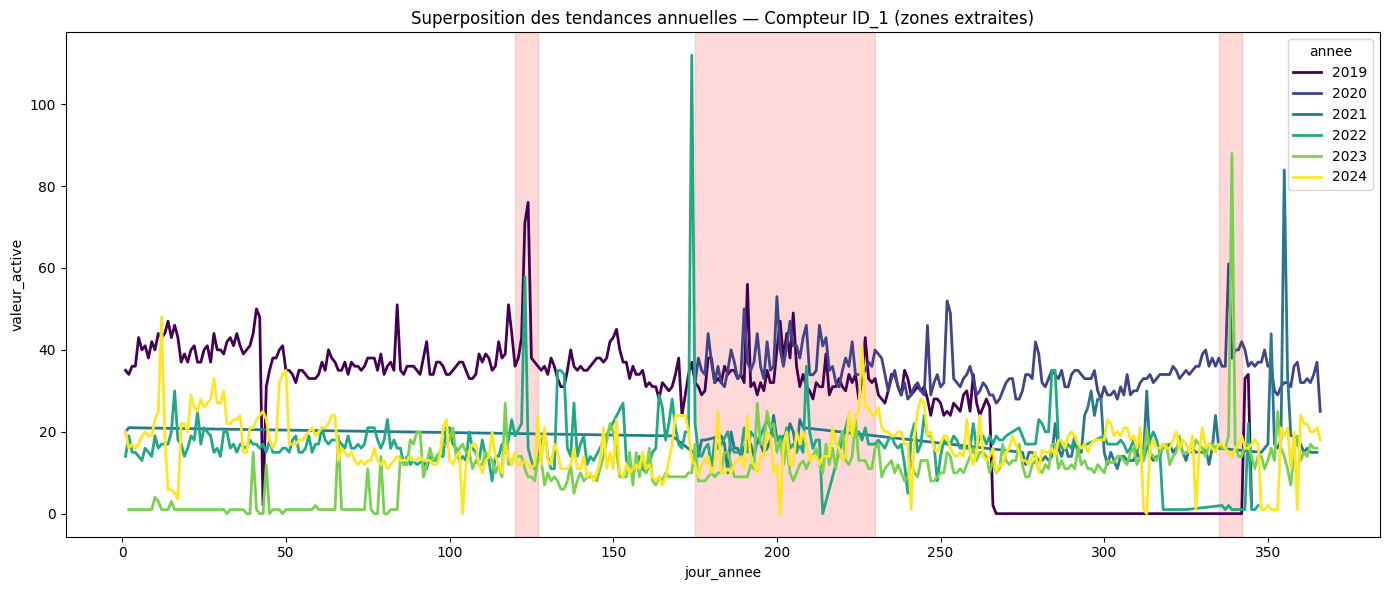

In [53]:
intervals = [
    ("periode_1", 120, 127), #2019 et 2022
    ("periode_2", 175, 230),
    ("periode_3", 335, 342),
]

plt.figure(figsize=(14,6))
sns.lineplot(data=df_id1, x="jour_annee", y="valeur_active", hue="annee", palette="viridis", linewidth=2)

for _, a, b in intervals:
    plt.axvspan(a, b, color="red", alpha=0.15)  # bande rouge

plt.title("Superposition des tendances annuelles — Compteur ID_1 (zones extraites)")
# plt.xlabel("Jour de l'année")
plt.ylabel("valeur_active")
plt.tight_layout()
plt.show()


* la première zone rouge correspond peut-etre à deux fuites survenue à la meme période sur deux années différentes (2019 et 2022)
* la deuxième zone rouge correspond à une période ou la tendance est plus ou moins similaire pour les années 2019 et 2020
* La troisème zone rouge correspond peut-etre à deux fuites survenue à la meme période sur deux années différentes (2021 et 2023)

==> Trouver pourquoi des fuites surviennent à la meme periode su différentes années ?

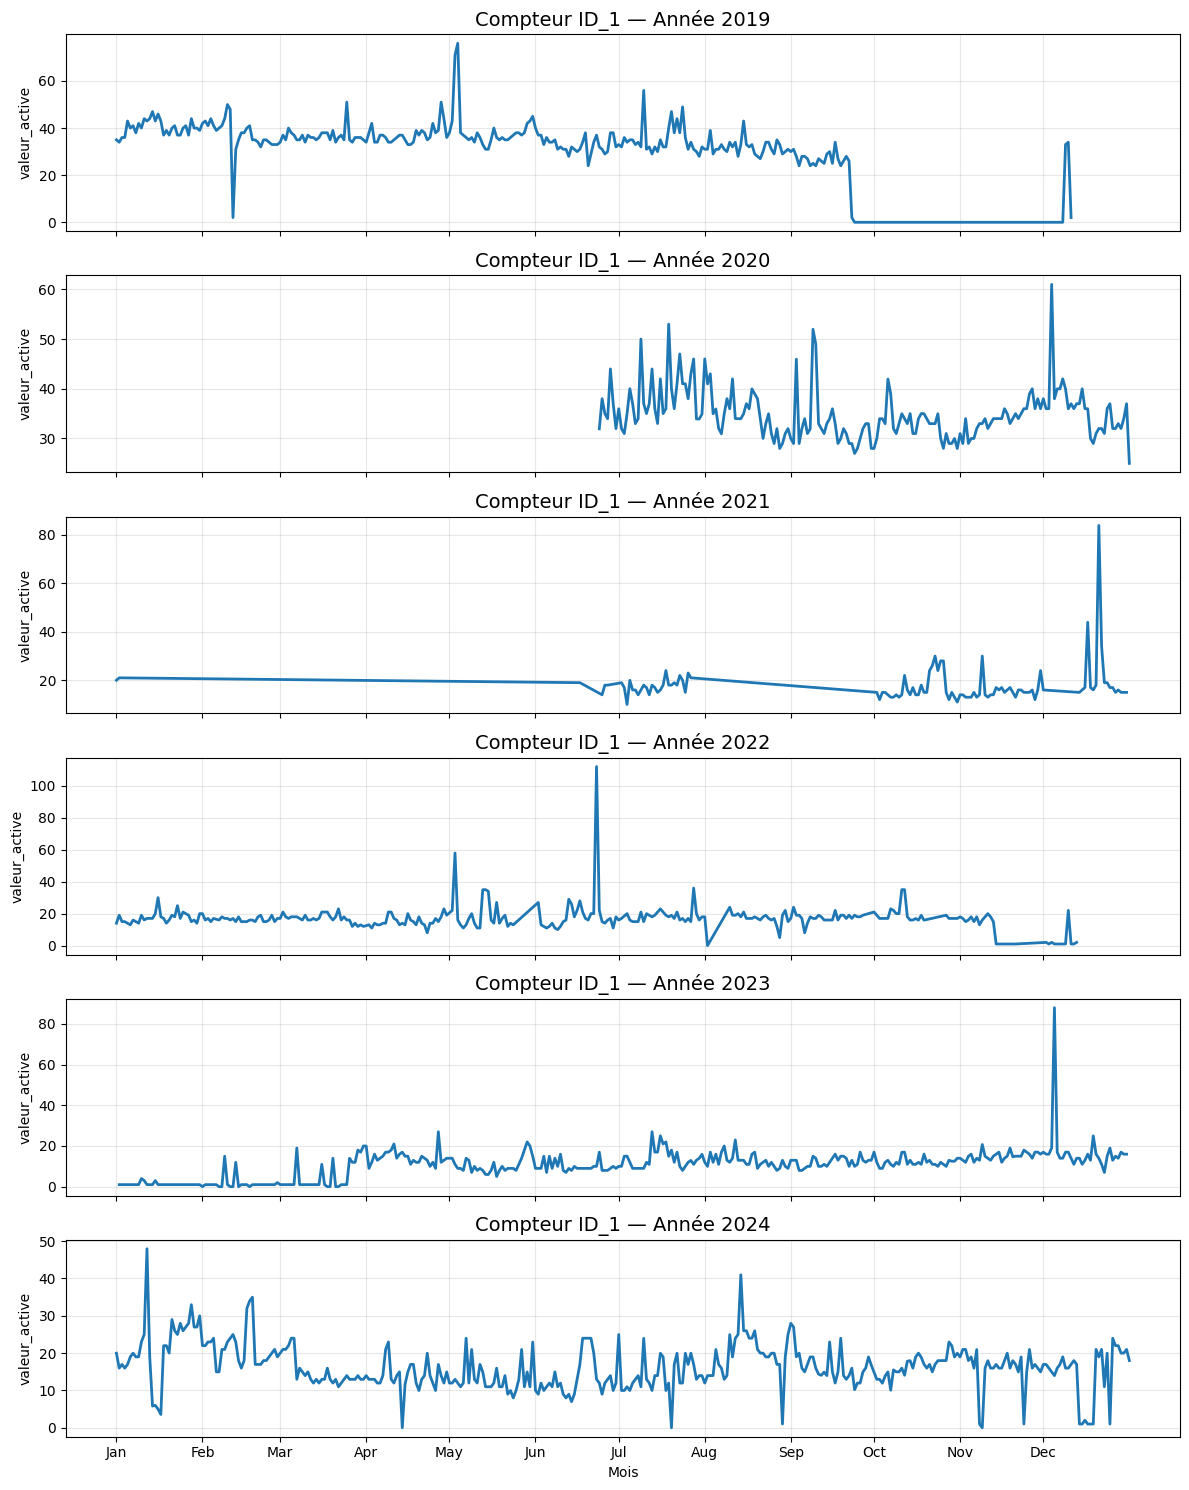

In [22]:
import calendar

# Visualisation avec subplots pour chaque année
annees = sorted(df_id1["annee"].unique())

fig, axes = plt.subplots(
    nrows=len(annees),
    ncols=1,
    figsize=(12, 2.5 * len(annees)),
    sharex=True
)

if len(annees) == 1:
    axes = [axes]

for ax, an in zip(axes, annees):
    tmp = df_id1[df_id1["annee"] == an]

    sns.lineplot(
        data=tmp,
        x="jour_annee",
        y="valeur_active",
        ax=ax,
        linewidth=2
    )

    ax.set_title(f"Compteur ID_1 — Année {an}", fontsize=14)
    ax.set_ylabel("valeur_active")
    ax.grid(True, alpha=0.3)

# ---- Ajout des mois sur l'axe X ----
dates_unique = pd.date_range(start=f"{annees[0]}-01-01", end=f"{annees[0]}-12-31", freq="MS")
mois_jour = [d.timetuple().tm_yday for d in dates_unique]
mois_labels = [calendar.month_abbr[d.month] for d in dates_unique]

axes[-1].set_xticks(mois_jour)
axes[-1].set_xticklabels(mois_labels, rotation=0)

axes[-1].set_xlabel("Mois")
plt.tight_layout()
plt.show()


* Outre les valeurs abbérantes, on remarque que les valeurs prélevées entre 2019 et 2021 sont plus élevées par rapport aux autres années
* Par contre, on constate des trous dans la première moitié de l'année 2021 et celle de l'année 2022.
* Pour ces périodes, il faudrait savoir si le compteur était inactif ou si les valeurs n'ont pas été relevées
* Les valeurs en 2022 et 2023 sont très faibles
* Valeurs non relevées pour la première moitié de l'année 2020, et pour les derniers jours de décembre 2019
* valeurs à 0 d'octobre à décembre 2019? le pic en décembre 2019 est surement une valeur abbérante
* Entre janvier et Juillet, la valeur active est contante , pourquoi?
* en 2024 Il y plus de consommation en eau sur toute l'année
* L'augmentation du débit en 2024 pourrait ètre du à l'augmentation du nombre d'utilisateurs au niveau du compteur ID_1


=> On peut supposer que les pics/outliers représentent des potentiels cas de fuite d'eau
- Verifier que les valeurs ont été bien notées

### Visualisation par jour de la semaine

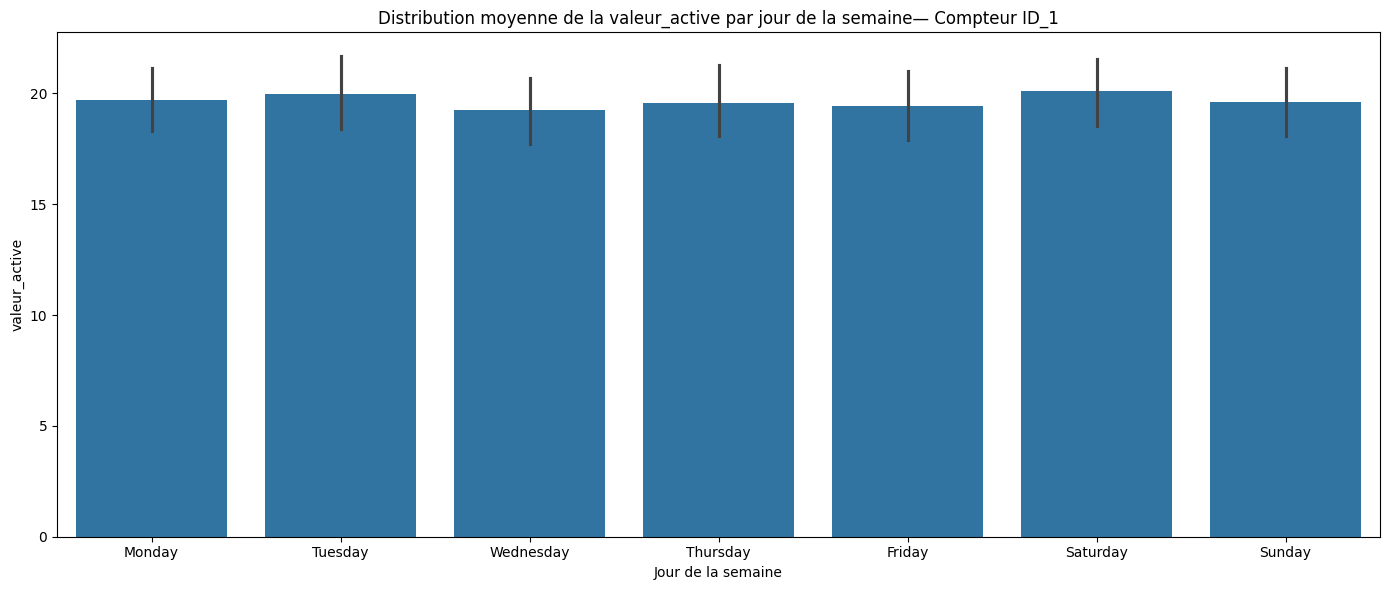

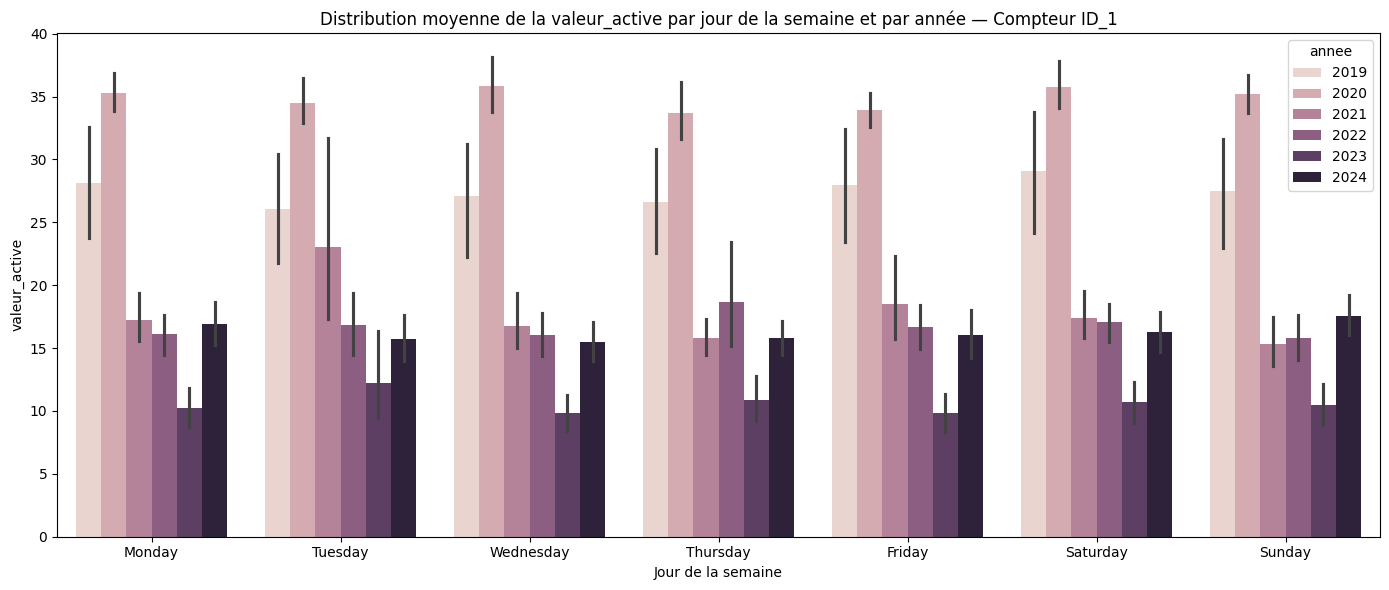

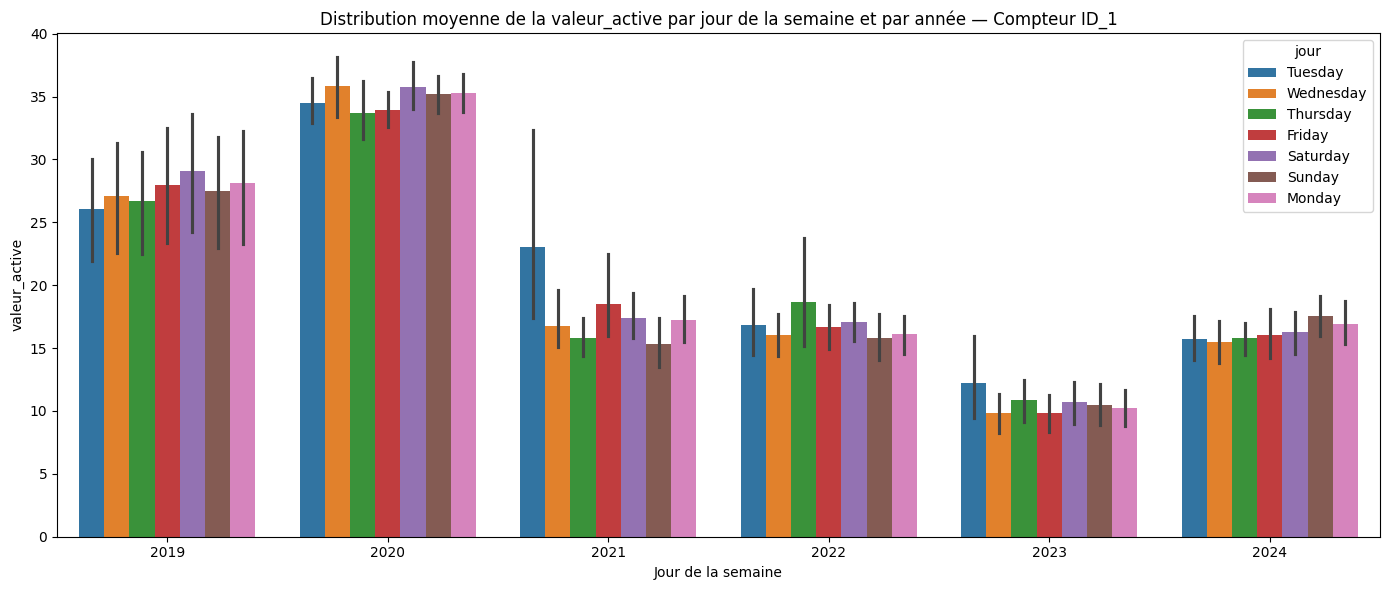

In [45]:

## Distribution moyenne de la valeur_active par jour de la semaine
plt.figure(figsize=(14,6))
ordre_jour = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.barplot(data=df_id1, x='jour', y='valeur_active', order=ordre_jour)
plt.title("Distribution moyenne de la valeur_active par jour de la semaine— Compteur ID_1")
plt.xlabel("Jour de la semaine")
plt.ylabel("valeur_active")
plt.tight_layout()
plt.show()


## Distribution moyenne de la valeur_active par jour de la semaine  et par année
plt.figure(figsize=(14,6))
ordre_jour = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.barplot(data=df_id1, x='jour', y='valeur_active',hue='annee', order=ordre_jour)
plt.title("Distribution moyenne de la valeur_active par jour de la semaine et par année — Compteur ID_1")
plt.xlabel("Jour de la semaine")
plt.ylabel("valeur_active")
plt.tight_layout()
plt.show()

## Distribution moyenne de la valeur_active  par année et par jour de la semaine
plt.figure(figsize=(14,6))
sns.barplot(data=df_id1, hue='jour', y='valeur_active',x='annee')
plt.title("Distribution moyenne de la valeur_active par jour de la semaine et par année — Compteur ID_1")
plt.xlabel("Jour de la semaine")
plt.ylabel("valeur_active")
plt.tight_layout()
plt.show()


* **Par jour :** on observe le meme parttern. La valeur est plus élevée en 2020 et moins en 2023. Difficile  de voir la relation entre ces deux variables avec ce plot.

* **Par année**: Difficile d'interpreter. Intervalle de confiance très large pour tous les jours de la semaine et en 2019 et pour le mardi en 2021. Surement peu de données pour l'évaluation

Diagramme ne sont pas très pertinent car les valeurs par jour de la semaine sont plus élevées pour les années ou la consommation était élevée

###  Visualisation par mois

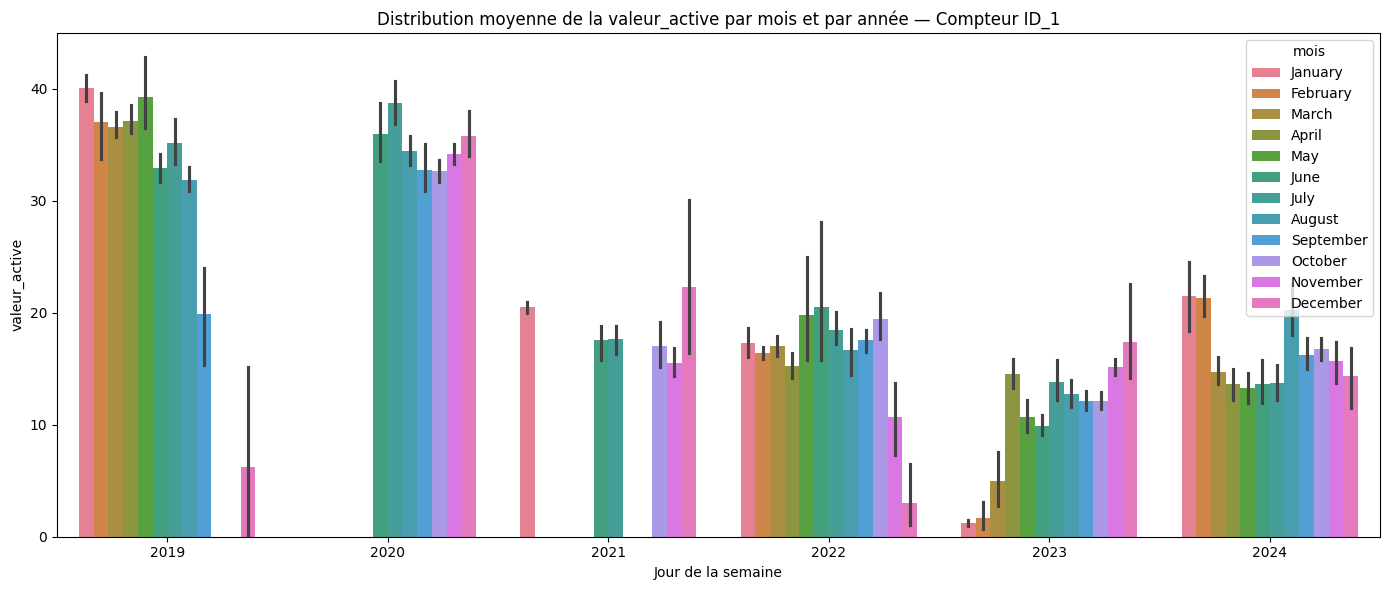

In [46]:
plt.figure(figsize=(14,6))
sns.barplot(data=df_id1, hue='mois', y='valeur_active',x='annee')
plt.title("Distribution moyenne de la valeur_active par mois et par année — Compteur ID_1")
plt.xlabel("Jour de la semaine")
plt.ylabel("valeur_active")
plt.tight_layout()
plt.show()

Le graphique montre que la valeur _active du compteur est très élevée  en 2019–2020, puis chute nettement à partir de 2021, avec une grande variabilité indiquant une utilisation irrégulière ou des données moins fiables. En 2023, l’activité s’effondre presque totalement, ce qui suggère une interruption, une panne ou un changement majeur d’utilisation. En 2024, les valeurs remontent mais restent bien en dessous des niveaux initiaux, indiquant une reprise partielle seulement.

# Résumé des Observations  (Compteur ID_1 uniquement)
### 1. Qualité et structure des données

Le compteur ID_1 possède des données globalement exploitables, mais avec des valeurs manquantes, notamment pour le 1er semestre de 2020 et la fin d'année 2019. Cela qui réduit la longueur réelle de la série utilisable.
Quelques valeurs aberrantes sont présentes : des pics isolés très élevés et des périodes d’activité quasi nulle.

Néanmoins, les courbes des années 2022,2023 et 2024 paraissent plus stables et plus cohérentes.

### 2. Analyse temporelle du compteur ID_1

🔹 Évolution générale

La valeur active du compteur ID_1 montre une forte variabilité avec des phases stables entrecoupées de pics soudains.



🔹 Présence de trous dans les données

Les périodes manquantes se concentrent dans la première moitié de la série.



### 3. Identification d’anomalies (ID_1)

Des pics soudains et très élevés apparaissent à certains moments, sans justification saisonnière ou hebdomadaire.

Certaines zones affichent des valeurs anormalement faibles ou nulles, incompatibles avec un fonctionnement normal.

Ces comportements peuvent indiquer :

une anomalie dans la consommation,

une défaillance du capteur,

ou un mauvais enregistrement des données.

## Conclusion générale (pour le compteur ID_1)

L’analyse du compteur ID_1 met en évidence une série temporelle exploitable mais marquée par des variations importantes, des anomalies ponctuelles et des données manquantes. Malgré ces limites, des patterns clairs se dégagent : une consommation plus forte durant la semaine, davantage de variabilité d’un mois à l’autre, et plusieurs valeurs atypiques susceptibles de signaler des anomalies ou des événements inhabituels.

Avant toute modélisation (détection de fuite ou prédiction), un nettoyage approfondi des données du compteur ID_1 reste essentiel :

suppression ou correction des valeurs aberrantes,

traitement des données manquantes,

lissage ou normalisation des variations extrêmes.

Cette préparation permettra d'obtenir un signal plus fiable et d’appuyer le développement d’un modèle robuste de détection de comportements anormaux pour le compteur ID_1.